In [2]:
# Hadejia River Watershed: Streamflow and Hydrological Analysis
# Study period: 1976–1990
# Gauge station: Wudil (GRDC ID: 1837410)

# Hadejia River Watershed: Streamflow and Hydrological Analysis

**Study Area:** Hadejia River Watershed, Nigeria  
**Gauge Station:** Wudil  
**GRDC Station ID:** 1837410  
**Analysis Period:** 1976–1990  
**Primary Data:** Daily observed streamflow discharge  
**Tools:** Python, Jupyter Notebook, QGIS

In [3]:
import pandas as pd
path = r"C:\Users\User pc\Desktop\CEEPLUS\SWAT\DATA\Hadejia.day"
with open(path, "r") as f:
    lines = f.readlines()
print(f"Total lines: {len(lines)}")
print("\n".join(lines[:20]))

Total lines: 24477
1837410  ID from GRDC discharge database; (Abfluss) DAILY

nodata   -9999.000

n       1 measurement per day [1, 1440]

start   1951 01 01 00 00 (YYYY MM DD HH MM)

end     2017 12 31 00 00 (YYYY MM DD HH MM)

1951 01 01 00 00   -9999.000 

1951 01 02 00 00   -9999.000 

1951 01 03 00 00   -9999.000 

1951 01 04 00 00   -9999.000 

1951 01 05 00 00   -9999.000 

1951 01 06 00 00   -9999.000 

1951 01 07 00 00   -9999.000 

1951 01 08 00 00   -9999.000 

1951 01 09 00 00   -9999.000 

1951 01 10 00 00   -9999.000 

1951 01 11 00 00   -9999.000 

1951 01 12 00 00   -9999.000 

1951 01 13 00 00   -9999.000 

1951 01 14 00 00   -9999.000 

1951 01 15 00 00   -9999.000 



In [4]:
with open(path, "r") as f:
    for i, line in enumerate(f.readlines()[:15], start=1):
        print(i, repr(line))

1 '1837410  ID from GRDC discharge database; (Abfluss) DAILY\n'
2 'nodata   -9999.000\n'
3 'n       1 measurement per day [1, 1440]\n'
4 'start   1951 01 01 00 00 (YYYY MM DD HH MM)\n'
5 'end     2017 12 31 00 00 (YYYY MM DD HH MM)\n'
6 '1951 01 01 00 00   -9999.000 \n'
7 '1951 01 02 00 00   -9999.000 \n'
8 '1951 01 03 00 00   -9999.000 \n'
9 '1951 01 04 00 00   -9999.000 \n'
10 '1951 01 05 00 00   -9999.000 \n'
11 '1951 01 06 00 00   -9999.000 \n'
12 '1951 01 07 00 00   -9999.000 \n'
13 '1951 01 08 00 00   -9999.000 \n'
14 '1951 01 09 00 00   -9999.000 \n'
15 '1951 01 10 00 00   -9999.000 \n'


In [5]:
data = pd.read_csv(
    path,
    sep=r"\s+",
    skiprows=5,
    header=None,
    names=["year", "month", "day", "hour", "minute", "discharge"]
)
data.head()

,year,month,day,hour,minute,discharge
0,1951,1,1,0,0,-9999.0
1,1951,1,2,0,0,-9999.0
2,1951,1,3,0,0,-9999.0
3,1951,1,4,0,0,-9999.0
4,1951,1,5,0,0,-9999.0


In [6]:
data["discharge"] = data["discharge"].replace(-9999.0, pd.NA)
data["date"] = pd.to_datetime(
    data[["year", "month", "day"]]
)
study_data = data[
    (data["date"] >= "1976-01-01") &
    (data["date"] <= "1990-12-31")
].copy()
study_data.head()

,year,month,day,hour,minute,discharge,date
9131,1976,1,1,0,0,1.219,1976-01-01
9132,1976,1,2,0,0,1.486,1976-01-02
9133,1976,1,3,0,0,1.631,1976-01-03
9134,1976,1,4,0,0,1.784,1976-01-04
9135,1976,1,5,0,0,1.784,1976-01-05


In [7]:
print("Number of observations:", len(study_data))
print("Start date:", study_data["date"].min())
print("End date:", study_data["date"].max())
print("Missing discharge values:", study_data["discharge"].isna().sum())
print("\nDischarge statistics:")
print(study_data["discharge"].describe())

Number of observations: 5479
Start date: 1976-01-01 00:00:00
End date: 1990-12-31 00:00:00
Missing discharge values: 0

Discharge statistics:
count     5479.000
unique     556.000
top         15.029
freq       102.000
Name: discharge, dtype: float64


In [8]:
study_data["discharge"] = pd.to_numeric(study_data["discharge"])
study_data["discharge"].describe()

count    5479.000000
mean       35.315727
std        58.087046
min         0.000000
25%         5.644000
50%        14.003000
75%        36.920000
max       704.684000
Name: discharge, dtype: float64

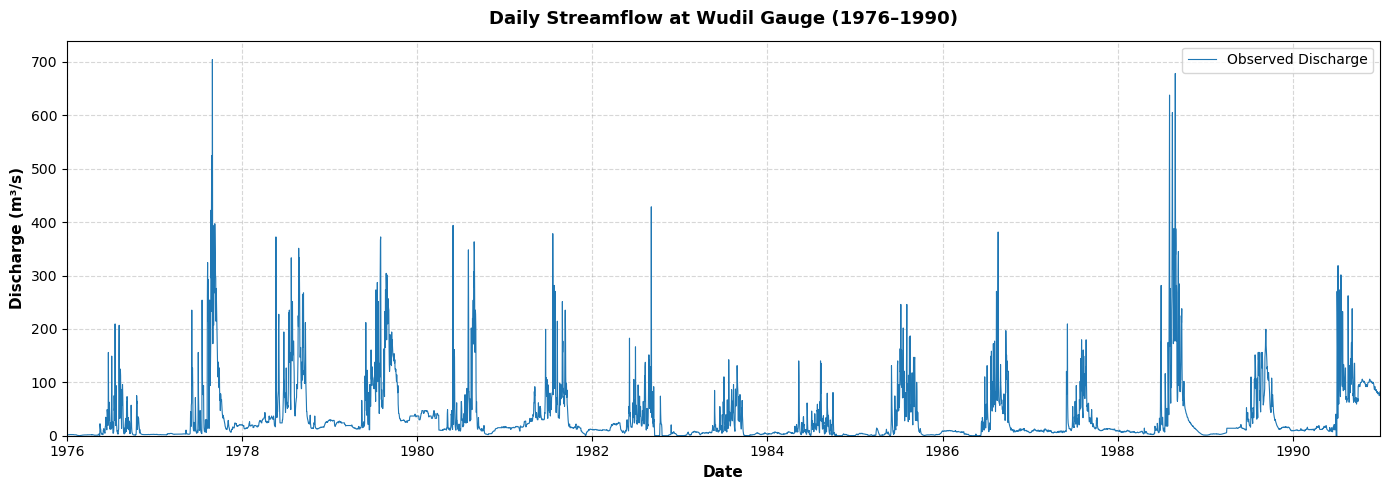

In [9]:
import matplotlib.pyplot as plt
study_data["date"] = pd.to_datetime(study_data["date"])
plt.figure(figsize=(14, 5))
plt.plot(
    study_data["date"], 
    study_data["discharge"], 
    color="#1f77b4", 
    linewidth=0.8, 
    label="Observed Discharge"
)
plt.xlabel("Date", fontsize=11, fontweight="bold")
plt.ylabel("Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Daily Streamflow at Wudil Gauge (1976–1990)", fontsize=13, fontweight="bold", pad=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(study_data["date"].min(), study_data["date"].max())
plt.ylim(bottom=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [10]:
monthly_flow = (
    study_data
    .set_index("date")["discharge"]
    .resample("ME")
    .mean()
)
monthly_flow.head()

date
1976-01-31    1.944000
1976-02-29    0.917897
1976-03-31    1.343258
1976-04-30    1.487467
1976-05-31    4.098806
Freq: ME, Name: discharge, dtype: float64

In [11]:
print(monthly_flow.head(12))
print("\nNumber of monthly values:", len(monthly_flow))

date
1976-01-31     1.944000
1976-02-29     0.917897
1976-03-31     1.343258
1976-04-30     1.487467
1976-05-31     4.098806
1976-06-30    27.023067
1976-07-31    39.063774
1976-08-31    52.379484
1976-09-30    25.147100
1976-10-31    15.437226
1976-11-30     2.713333
1976-12-31     2.344194
Freq: ME, Name: discharge, dtype: float64

Number of monthly values: 180


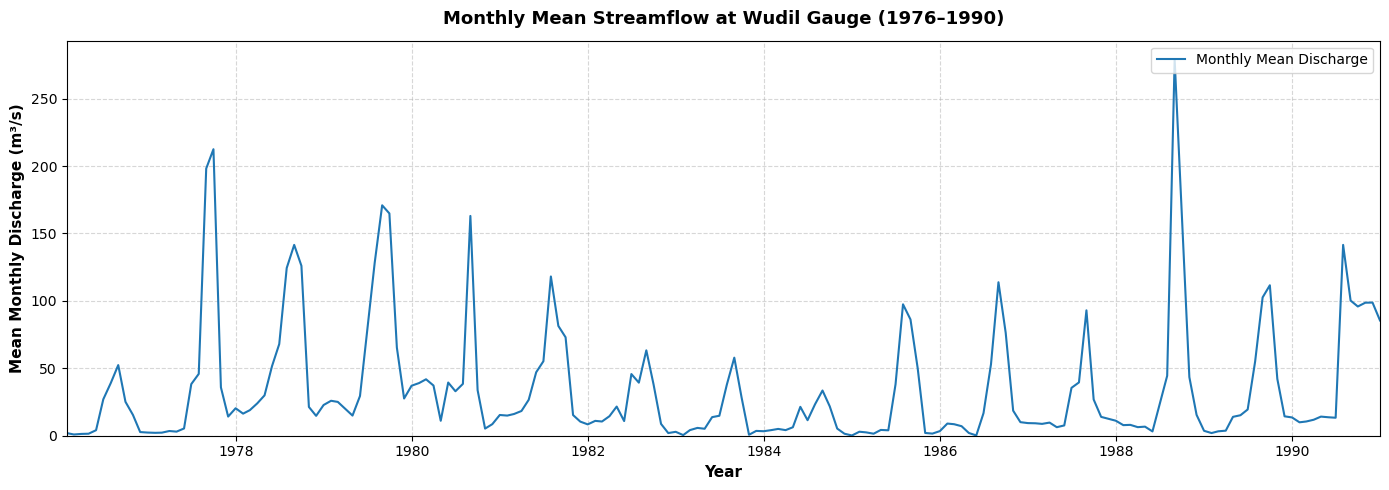

In [12]:
if not isinstance(monthly_flow.index, pd.DatetimeIndex):
    monthly_flow.index = monthly_flow.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(
    monthly_flow.index, 
    monthly_flow.values, 
    color="#1f77b4", 
    linewidth=1.5, 
    label="Monthly Mean Discharge"
)
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Mean Monthly Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Monthly Mean Streamflow at Wudil Gauge (1976–1990)", fontsize=13, fontweight="bold", pad=12)
plt.xlim(monthly_flow.index.min(), monthly_flow.index.max())
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [13]:
annual_flow = (
    study_data
    .set_index("date")["discharge"]
    .resample("YE")
    .mean()
)
print(annual_flow)

date
1976-12-31    14.570167
1977-12-31    48.633488
1978-12-31    55.213890
1979-12-31    65.877682
1980-12-31    39.011423
1981-12-31    40.612266
1982-12-31    22.434356
1983-12-31    14.779414
1984-12-31    11.562645
1985-12-31    24.695370
1986-12-31    27.224855
1987-12-31    22.993833
1988-12-31    50.692634
1989-12-31    33.255986
1990-12-31    58.247559
Freq: YE-DEC, Name: discharge, dtype: float64


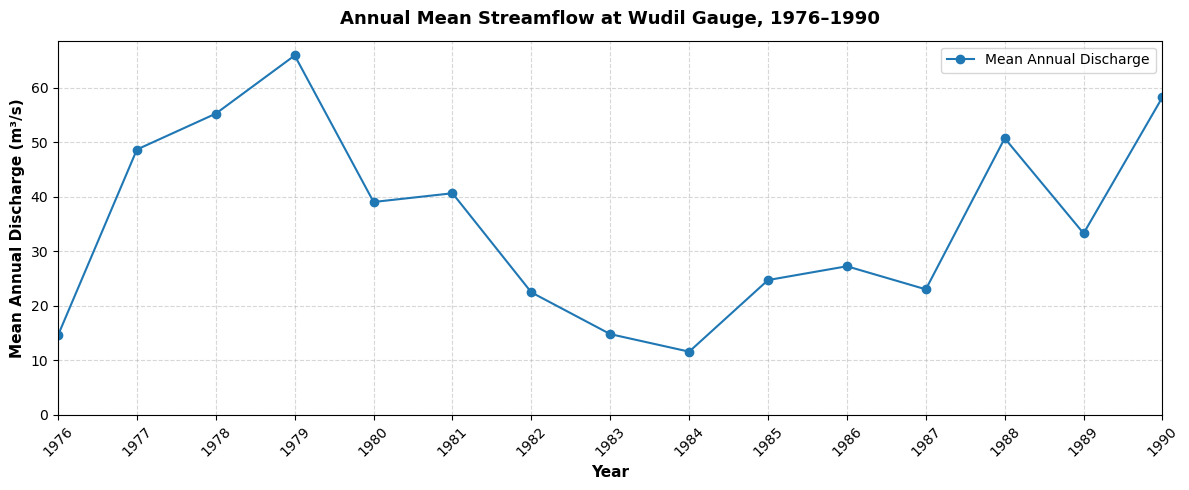

In [14]:
if hasattr(annual_flow.index, 'year'):
    x_years = annual_flow.index.year
else:
    x_years = annual_flow.index

plt.figure(figsize=(12, 5))
plt.plot(
    x_years, 
    annual_flow.values, 
    marker="o", 
    color="#1f77b4", 
    linewidth=1.5, 
    markersize=6,
    label="Mean Annual Discharge"
)
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Mean Annual Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Annual Mean Streamflow at Wudil Gauge, 1976–1990", fontsize=13, fontweight="bold", pad=12)

plt.xlim(min(x_years), max(x_years))
plt.xticks(range(min(x_years), max(x_years) + 1), rotation=45)
plt.ylim(bottom=0)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
flow_sorted = np.sort(study_data["discharge"].values)[::-1]
exceedance_probability = (
    np.arange(1, len(flow_sorted) + 1)
    / (len(flow_sorted) + 1)
) * 100
flow_duration = pd.DataFrame({
    "discharge": flow_sorted,
    "exceedance_probability": exceedance_probability
})
flow_duration.head()

,discharge,exceedance_probability
0,704.684,0.018248
1,678.489,0.036496
2,637.982,0.054745
3,605.447,0.072993
4,524.859,0.091241


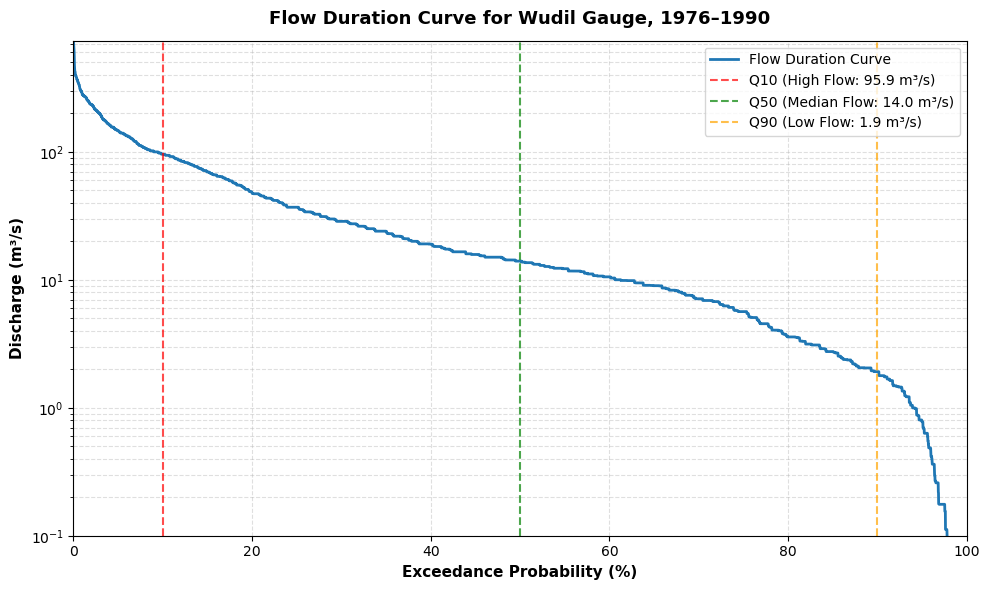

In [16]:
q10 = np.percentile(flow_duration["discharge"], 90)
q50 = np.percentile(flow_duration["discharge"], 50)
q90 = np.percentile(flow_duration["discharge"], 10)

plt.figure(figsize=(10, 6))
plt.plot(
    flow_duration["exceedance_probability"], 
    flow_duration["discharge"], 
    color="#1f77b4", 
    linewidth=2, 
    label="Flow Duration Curve"
)

plt.axvline(10, color="red", linestyle="--", alpha=0.7, label=f"Q10 (High Flow: {q10:.1f} m³/s)")
plt.axvline(50, color="green", linestyle="--", alpha=0.7, label=f"Q50 (Median Flow: {q50:.1f} m³/s)")
plt.axvline(90, color="orange", linestyle="--", alpha=0.7, label=f"Q90 (Low Flow: {q90:.1f} m³/s)")

plt.xlabel("Exceedance Probability (%)", fontsize=11, fontweight="bold")
plt.ylabel("Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Flow Duration Curve for Wudil Gauge, 1976–1990", fontsize=13, fontweight="bold", pad=12)

plt.xlim(0, 100)
plt.ylim(bottom=0.1) 
plt.yscale("log")      

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [17]:
zero_flow = (study_data["discharge"] == 0).sum()

print("Number of zero-flow days:", zero_flow)
print("Percentage of study period:", (zero_flow / len(study_data)) * 100)

Number of zero-flow days: 60
Percentage of study period: 1.0950903449534586


In [18]:
zero_flow_dates = study_data.loc[
    study_data["discharge"] == 0,
    "date"
]
print(zero_flow_dates.to_list())

[Timestamp('1982-09-27 00:00:00'), Timestamp('1982-09-28 00:00:00'), Timestamp('1982-10-29 00:00:00'), Timestamp('1982-10-30 00:00:00'), Timestamp('1982-10-31 00:00:00'), Timestamp('1982-11-02 00:00:00'), Timestamp('1982-11-03 00:00:00'), Timestamp('1982-11-04 00:00:00'), Timestamp('1982-11-05 00:00:00'), Timestamp('1982-11-06 00:00:00'), Timestamp('1982-11-07 00:00:00'), Timestamp('1983-01-09 00:00:00'), Timestamp('1983-01-10 00:00:00'), Timestamp('1984-10-18 00:00:00'), Timestamp('1984-10-19 00:00:00'), Timestamp('1984-10-20 00:00:00'), Timestamp('1984-10-21 00:00:00'), Timestamp('1984-10-22 00:00:00'), Timestamp('1984-10-23 00:00:00'), Timestamp('1984-10-24 00:00:00'), Timestamp('1984-10-25 00:00:00'), Timestamp('1984-10-26 00:00:00'), Timestamp('1984-10-27 00:00:00'), Timestamp('1984-10-28 00:00:00'), Timestamp('1984-10-31 00:00:00'), Timestamp('1984-11-01 00:00:00'), Timestamp('1984-11-02 00:00:00'), Timestamp('1984-11-03 00:00:00'), Timestamp('1984-11-04 00:00:00'), Timestamp('19

In [19]:
zero_flow_by_year = (
    study_data[study_data["discharge"] == 0]
    .set_index("date")
    .resample("YE")
    .size()
)
print(zero_flow_by_year[zero_flow_by_year > 0])

date
1982-12-31    11
1983-12-31     2
1984-12-31    28
1986-12-31    17
1990-12-31     2
dtype: int64


In [20]:
monthly_climatology = (
    study_data
    .set_index("date")["discharge"]
    .groupby(lambda x: x.month)
    .mean()
)
monthly_climatology.index = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
print(monthly_climatology)

Jan     10.466305
Feb     11.134226
Mar     11.267892
Apr     11.182333
May     17.802695
Jun     34.559509
Jul     68.375148
Aug    115.795755
Sep     83.210111
Oct     26.148387
Nov     15.872124
Dec     15.956983
Name: discharge, dtype: float64


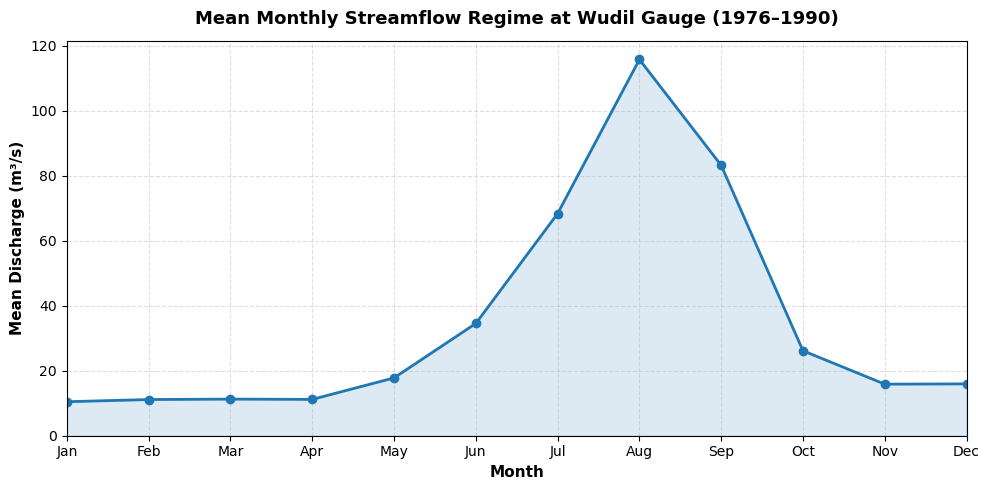

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_climatology.index, 
    monthly_climatology.values, 
    marker="o", 
    color="#1f77b4", 
    linewidth=2, 
    markersize=6,
    label="Mean Monthly Climatology"
)

plt.fill_between(
    monthly_climatology.index, 
    monthly_climatology.values, 
    color="#1f77b4", 
    alpha=0.15
)

plt.xlabel("Month", fontsize=11, fontweight="bold")
plt.ylabel("Mean Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Mean Monthly Streamflow Regime at Wudil Gauge (1976–1990)", fontsize=13, fontweight="bold", pad=12)

plt.xlim(0, 11)  
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [22]:
high_flow_threshold = np.percentile(study_data["discharge"], 90)
low_flow_threshold = np.percentile(study_data["discharge"], 10)

high_flow_days = (study_data["discharge"] >= high_flow_threshold).sum()
low_flow_days = (study_data["discharge"] <= low_flow_threshold).sum()

print(f"High-flow threshold (90th percentile): {high_flow_threshold:.2f} m³/s")
print(f"Number of high-flow days: {high_flow_days}")

print(f"\nLow-flow threshold (10th percentile): {low_flow_threshold:.2f} m³/s")
print(f"Number of low-flow days: {low_flow_days}")

High-flow threshold (90th percentile): 95.94 m³/s
Number of high-flow days: 552

Low-flow threshold (10th percentile): 1.92 m³/s
Number of low-flow days: 555


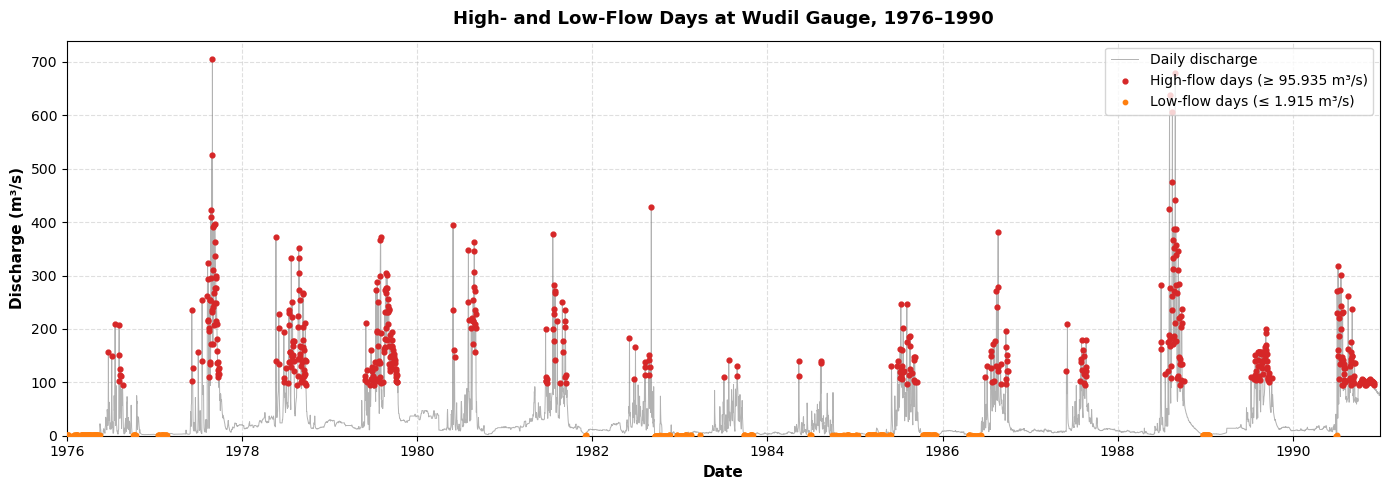

In [23]:
study_data["date"] = pd.to_datetime(study_data["date"])

high_flow = study_data["discharge"] >= high_flow_threshold
low_flow = study_data["discharge"] <= low_flow_threshold

plt.figure(figsize=(14, 5))

plt.plot(
    study_data["date"],
    study_data["discharge"],
    color="#7f7f7f", 
    linewidth=0.7,
    alpha=0.6,
    label="Daily discharge"
)

plt.scatter(
    study_data.loc[high_flow, "date"],
    study_data.loc[high_flow, "discharge"],
    color="#d62728", 
    s=12,
    zorder=3,
    label=f"High-flow days (≥ {high_flow_threshold} m³/s)"
)

plt.scatter(
    study_data.loc[low_flow, "date"],
    study_data.loc[low_flow, "discharge"],
    color="#ff7f0e",
    s=10,
    zorder=3,
    label=f"Low-flow days (≤ {low_flow_threshold} m³/s)"
)

plt.xlabel("Date", fontsize=11, fontweight="bold")
plt.ylabel("Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("High- and Low-Flow Days at Wudil Gauge, 1976–1990", fontsize=13, fontweight="bold", pad=12)

plt.xlim(study_data["date"].min(), study_data["date"].max())
plt.ylim(bottom=0)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()

plt.show()

In [24]:
annual_cv = (
    study_data
    .set_index("date")["discharge"]
    .resample("YE")
    .agg(["mean", "std"])
)

annual_cv["cv_percent"] = (
    annual_cv["std"] / annual_cv["mean"]
) * 100

print(annual_cv.round(2))

             mean     std  cv_percent
date                                 
1976-12-31  14.57   28.41      194.97
1977-12-31  48.63   93.83      192.94
1978-12-31  55.21   64.48      116.79
1979-12-31  65.88   68.78      104.41
1980-12-31  39.01   58.53      150.04
1981-12-31  40.61   49.44      121.73
1982-12-31  22.43   34.61      154.28
1983-12-31  14.78   22.92      155.10
1984-12-31  11.56   18.90      163.42
1985-12-31  24.70   43.24      175.09
1986-12-31  27.22   45.35      166.57
1987-12-31  22.99   30.40      132.21
1988-12-31  50.69  100.60      198.46
1989-12-31  33.26   42.58      128.04
1990-12-31  58.25   57.09       98.01


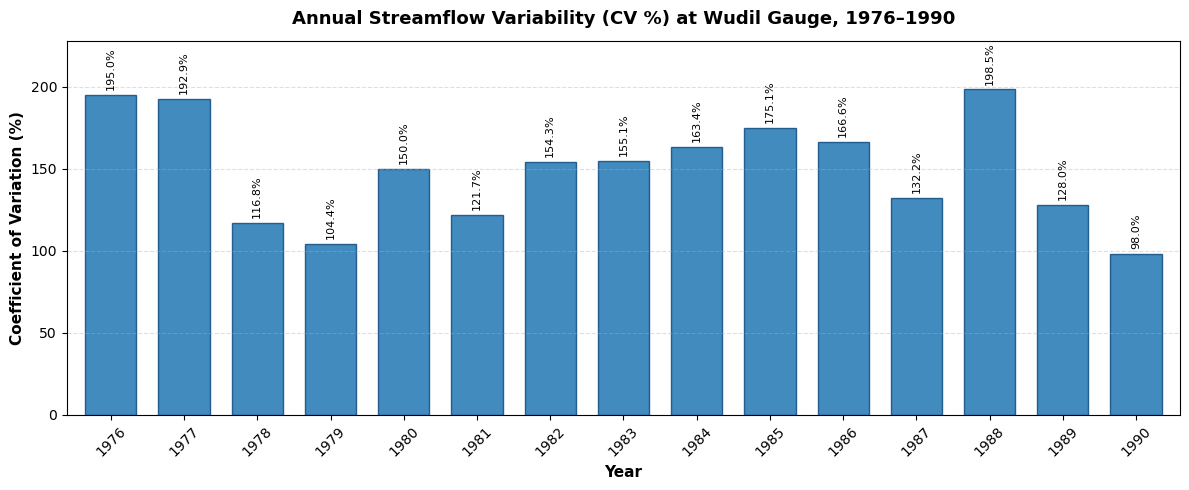

In [25]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    annual_cv.index.year,
    annual_cv["cv_percent"],
    color="#1f77b4",
    edgecolor="#0f4c81",
    width=0.7,
    alpha=0.85
)

plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Coefficient of Variation (%)", fontsize=11, fontweight="bold")
plt.title("Annual Streamflow Variability (CV %) at Wudil Gauge, 1976–1990", fontsize=13, fontweight="bold", pad=12)

plt.xticks(annual_cv.index.year, rotation=45)
plt.xlim(annual_cv.index.year.min() - 0.6, annual_cv.index.year.max() + 0.6)
plt.ylim(0, max(annual_cv["cv_percent"]) * 1.15)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + 3, 
        f"{yval:.1f}%", 
        ha="center", 
        va="bottom", 
        fontsize=8, 
        rotation=90
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

## Watershed Terrain and Morphometric Analysis

In [26]:
# Area-weighted mean slope

slope_means = {
    10: 1.549172365917,
    1: 1.543167865815,
    9: 1.642440672277,
    3: 1.979452860776,
    4: 1.891552855603,
    2: 2.161763099532,
    7: 1.804982612136,
    8: 2.051236578881,
    6: 1.908216341040,
    5: 3.075950233437
}

cell_counts = {
    10: 1251462,
    1: 444543,
    9: 1658113,
    3: 108147,
    4: 1376688,
    2: 4636658,
    7: 5754476,
    8: 2284749,
    6: 1518119,
    5: 5394433
}

weighted_slope = sum(
    slope_means[subbasin] * cell_counts[subbasin]
    for subbasin in slope_means
) / sum(cell_counts.values())

print(f"Area-weighted mean slope: {weighted_slope:.4f}°")

Area-weighted mean slope: 2.1596°


## Streamflow Trend Analysis

The temporal trend in annual mean streamflow was assessed for the 1976–1990 study period using the annual mean discharge series derived from the daily observations at the Wudil gauge. A linear regression was used to quantify the direction and magnitude of the relationship between year and annual mean discharge.

In [27]:
from scipy.stats import linregress

years = annual_flow.index.year
annual_values = annual_flow.values

trend = linregress(years, annual_values)

print(f"Slope: {trend.slope:.4f} m³/s per year")
print(f"Intercept: {trend.intercept:.4f} m³/s")
print(f"R²: {trend.rvalue**2:.4f}")
print(f"p-value: {trend.pvalue:.4f}")

Slope: -0.2098 m³/s per year
Intercept: 451.2557 m³/s
R²: 0.0029
p-value: 0.8485


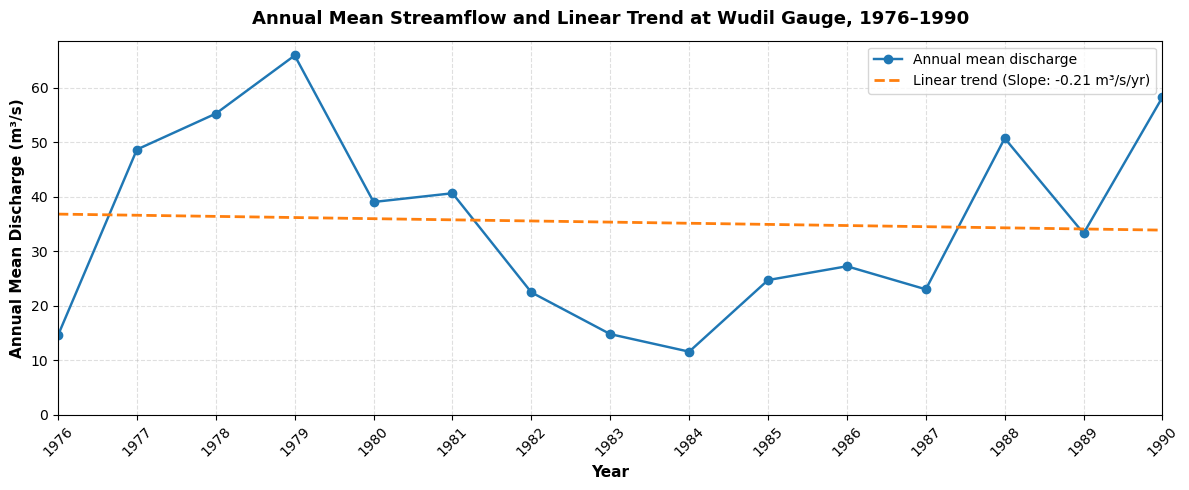

In [30]:
slope_str = f"Slope: {trend.slope:.2f} m³/s/yr"
r_value_str = f"R²: {trend.rvalue**2:.3f}" if hasattr(trend, 'rvalue') else ""

plt.figure(figsize=(12, 5))

# Annual Mean Discharge Line
plt.plot(
    years,
    annual_values,
    marker="o",
    color="#1f77b4",
    linewidth=1.75,
    markersize=6,
    label="Annual mean discharge"
)

# Trend Line
plt.plot(
    years,
    trend_values,
    linestyle="--",
    color="#ff7f0e",
    linewidth=2,
    label=f"Linear trend ({slope_str})"
)

plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("Annual Mean Discharge (m³/s)", fontsize=11, fontweight="bold")
plt.title("Annual Mean Streamflow and Linear Trend at Wudil Gauge, 1976–1990", fontsize=13, fontweight="bold", pad=12)

plt.xlim(min(years), max(years))
plt.xticks(range(int(min(years)), int(max(years)) + 1), rotation=45)
plt.ylim(bottom=0)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()

plt.show()

## Integrated Hydrological Interpretation

The Hadejia River watershed covers approximately 22,619.66 km², with a mean elevation of 552.53 m and an elevation range of 334.07–1,568.76 m, giving a relief of 1,234.69 m. The area-weighted mean slope is relatively low at 2.16°, while the watershed-specific slope analysis ranges from approximately 0° to 47.30°, indicating that steeper terrain occurs locally within the watershed. The QSWAT-derived drainage network contains 791.96 km of mapped reaches, corresponding to a mapped drainage density of 0.0350 km/km². The mapped network reaches a maximum stream order of 3rd order.

The observed streamflow record at the Wudil gauge contains **5,479 daily observations** covering **1976–1990**, with no missing discharge values after quality control. The mean discharge was **35.32 m³/s**, while the median was **14.00 m³/s**, indicating that higher-flow events substantially increase the overall mean. The flow-duration analysis also shows considerable variation between relatively high- and low-flow conditions, with **Q10 = 95.9 m³/s**, **Q50 = 14.0 m³/s**, and **Q90 = 1.9 m³/s**.

The monthly climatology shows a clear seasonal pattern. Streamflow is generally lower from January to April, increases during May and June, reaches its highest average value in **August (115.80 m³/s)**, and declines through September and October. A total of **60 recorded zero-discharge days** occurred during the study period, concentrated in a small number of years. These observations describe the temporal behaviour of the gauge record but do not by themselves establish the causes of the observed variations.

The annual mean discharge series varies considerably between years. A simple linear regression produced a slope of **−0.21 m³/s/year**, but the **R² of 0.0029** indicates that the fitted line explains very little of the variation, while the **p-value of 0.8485** provides no statistical evidence of a detectable linear trend over the 1976–1990 period.

Overall, the analysis shows a watershed with substantial spatial variation in terrain and a mapped drainage network, together with strong seasonal and short-term variability in observed streamflow. The GIS analysis provides the physical watershed context, while the observed discharge analysis describes how streamflow varied through time at Wudil. The results should be interpreted as a combined assessment of watershed characteristics and observed hydrological behaviour rather than as a causal rainfall–runoff model.
